In [12]:
import matplotlib.pyplot as plt
import os
import pandas as pd

In [25]:
# Load all predictions CV for all the models here 
LSTM_PRED_PATH = "../forecast evaluations/lstm_outputs/lstm_rolling_oos_predictions.csv"
HAR_PRED_PATH  = "../forecast evaluations/har_outputs/har_family_rolling_oos_predictions.csv"

OUT_DIR = "../figs/all_models"
os.makedirs(OUT_DIR, exist_ok=True)

HORIZONS = [1, 3, 5, 7]


In [26]:
# ---------- LOAD + STANDARDIZE LSTM ----------
lstm = pd.read_csv(LSTM_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
lstm["date"] = pd.to_datetime(lstm["date"], dayfirst=True, errors="raise")

# ensure correct types
lstm["h"] = lstm["h"].astype(int)

# create model column so it matches HAR format
if "model" not in lstm.columns:
    lstm["model"] = "LSTM"

print(lstm.head(3))

        date  h    y_true    y_pred     error model
0 2024-06-29  1 -8.047432 -8.234467  0.187035  LSTM
1 2024-06-30  1 -8.009439 -7.988692 -0.020747  LSTM
2 2024-07-01  1 -8.415744 -7.492826 -0.922918  LSTM


/var/folders/56/jfcfpz9j7jddpghsmvgv_mfr0000gn/T/ipykernel_79892/3870242691.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  lstm["date"] = pd.to_datetime(lstm["date"], dayfirst=True, errors="raise")


In [27]:
# ---------- LOAD + STANDARDIZE HAR ----------
har = pd.read_csv(HAR_PRED_PATH)

# parse date format like 29/6/24 (d/m/yy)
har["date"] = pd.to_datetime(har["date"], dayfirst=True, errors="raise")

print(har.head(3))

        date   model  h    y_true    y_pred     error
0 2024-06-29  HAR-RV  1 -8.047432 -7.808740 -0.238692
1 2024-06-30  HAR-RV  1 -8.009439 -8.165342  0.155903
2 2024-07-01  HAR-RV  1 -8.415744 -8.018623 -0.397121


/var/folders/56/jfcfpz9j7jddpghsmvgv_mfr0000gn/T/ipykernel_79892/2327861109.py:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  har["date"] = pd.to_datetime(har["date"], dayfirst=True, errors="raise")


In [29]:
# Combine dataframe 
preds = pd.concat([lstm, har], ignore_index=True)
print(preds.head(3))

        date  h    y_true    y_pred     error model
0 2024-06-29  1 -8.047432 -8.234467  0.187035  LSTM
1 2024-06-30  1 -8.009439 -7.988692 -0.020747  LSTM
2 2024-07-01  1 -8.415744 -7.492826 -0.922918  LSTM


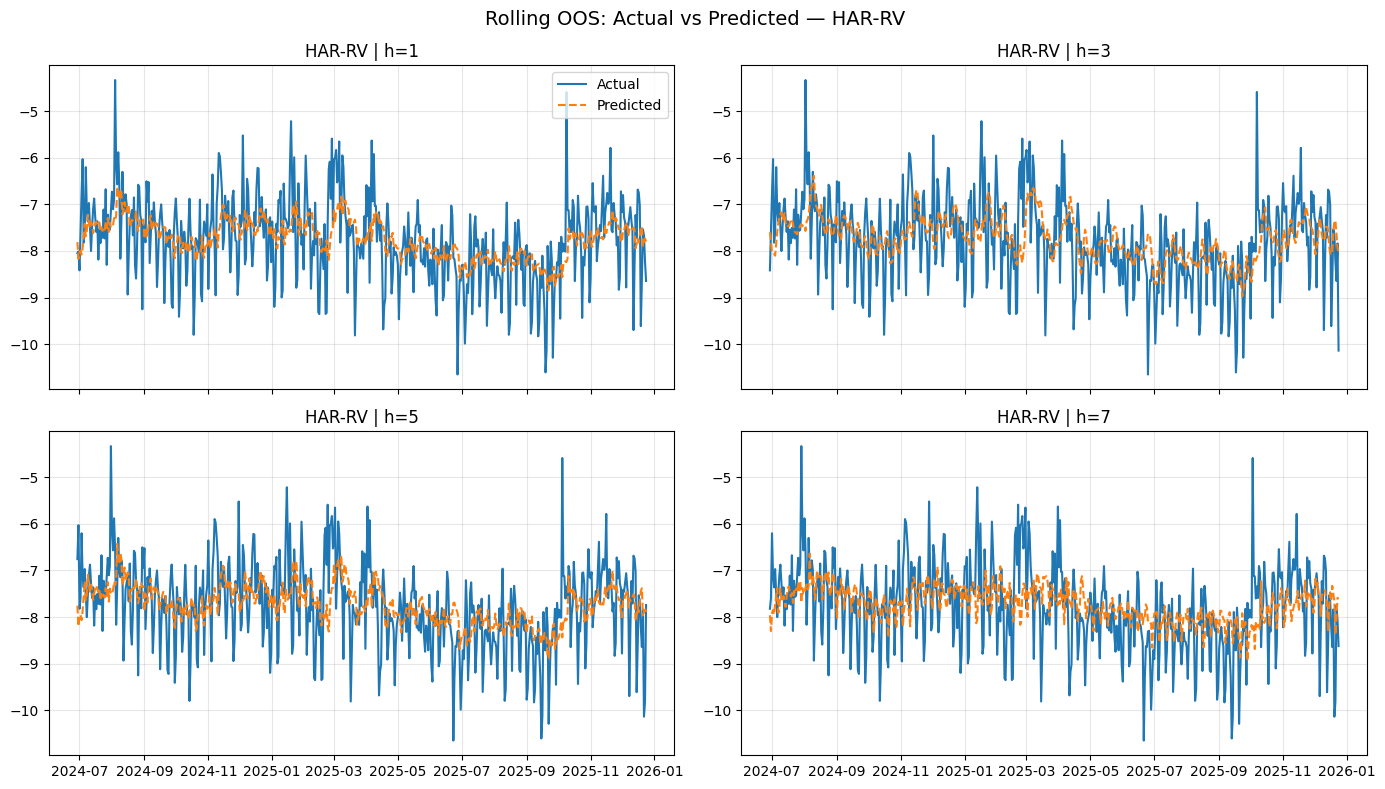

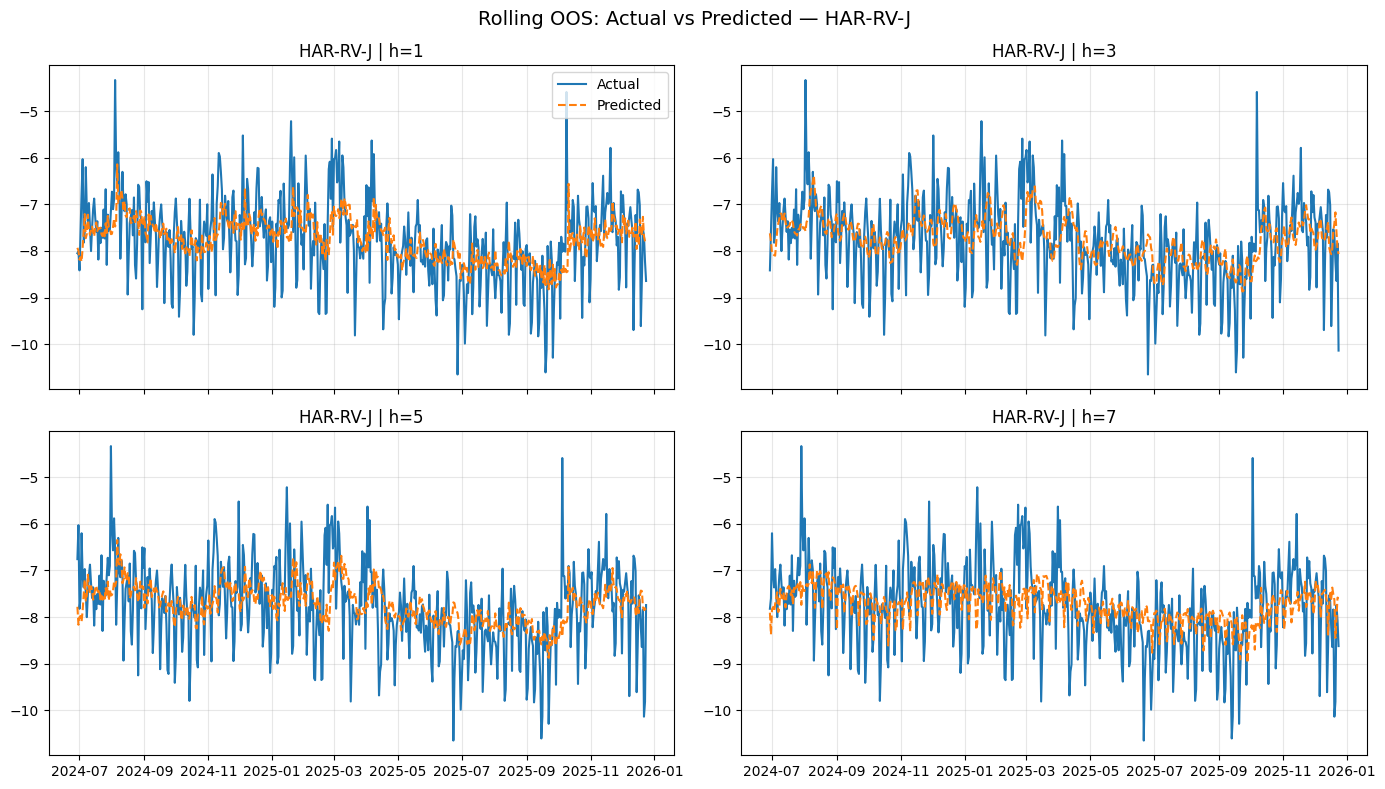

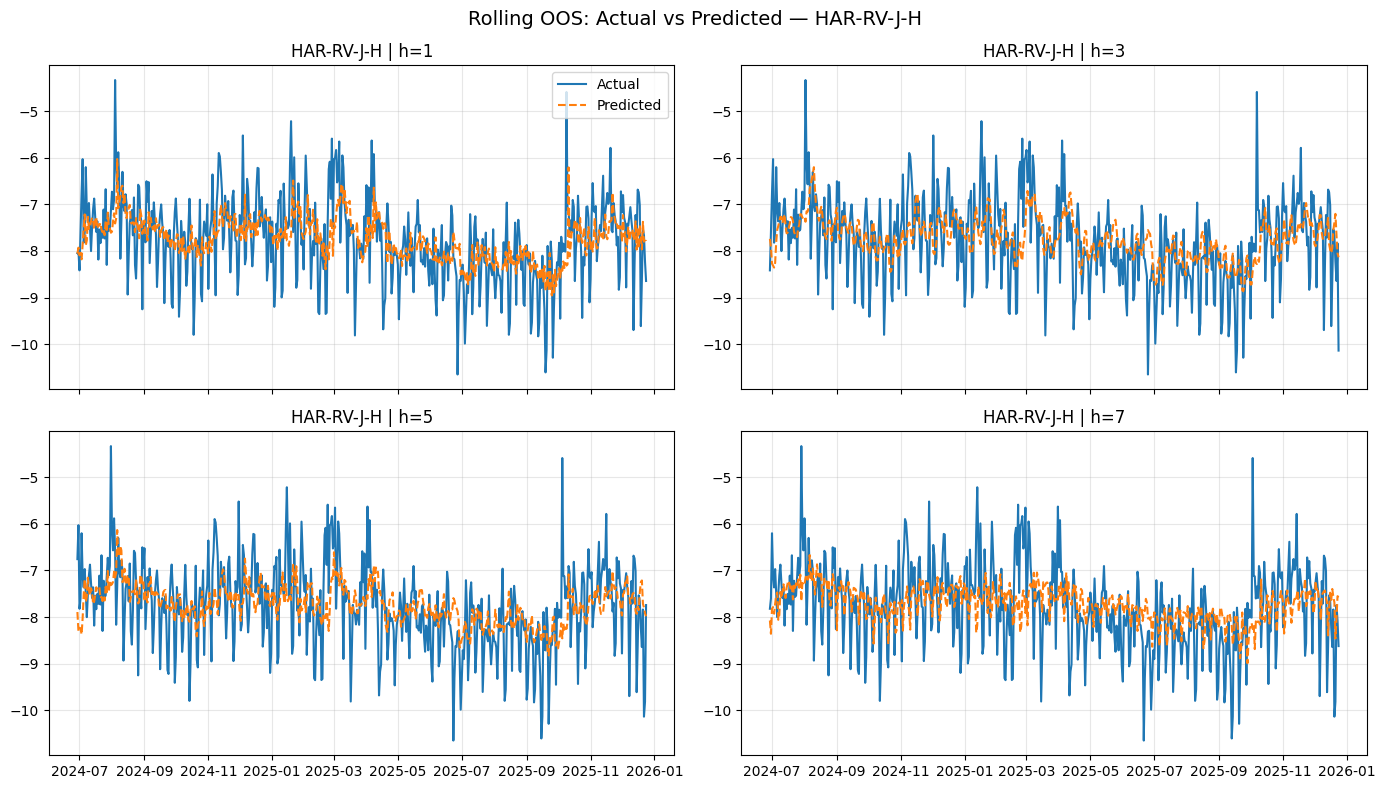

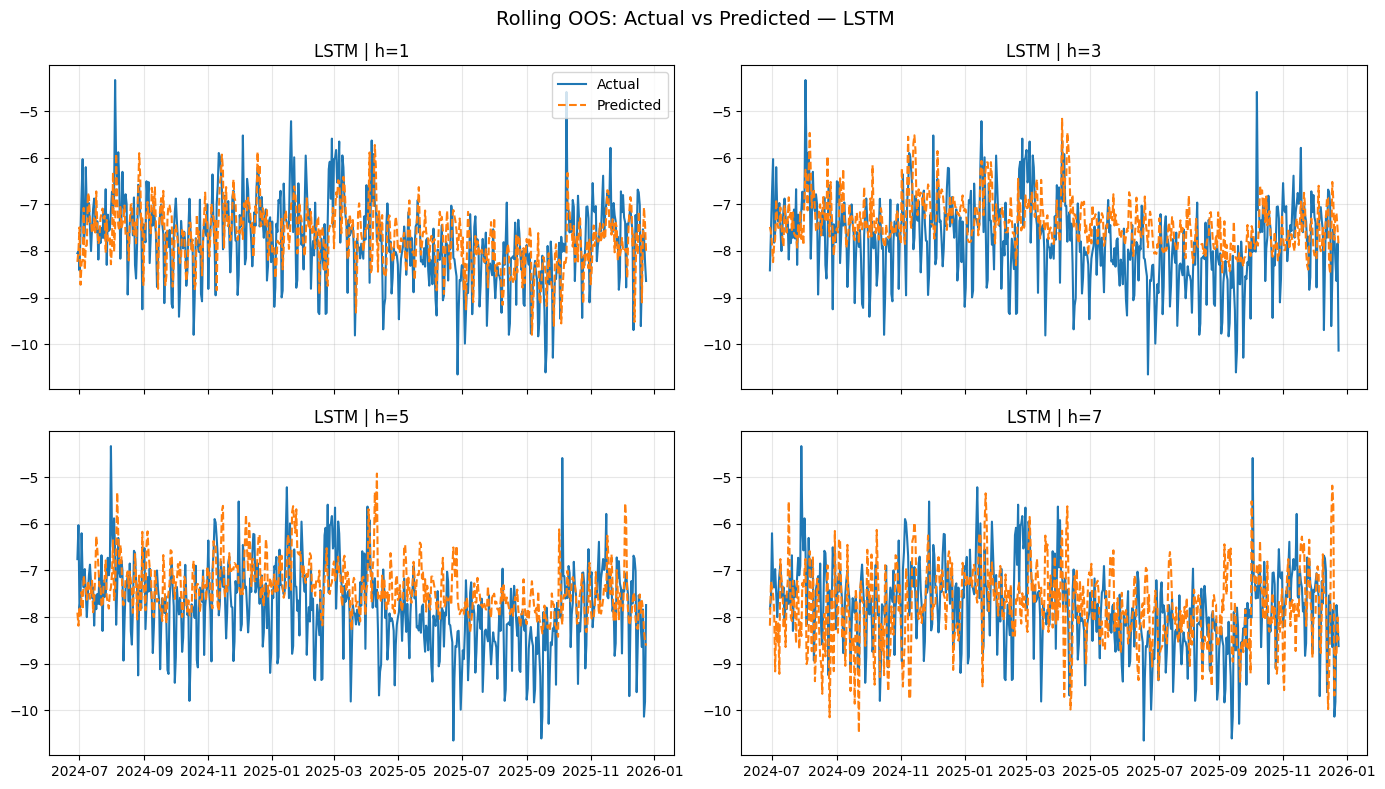

Saved all plots to: ../figs/all_models


In [30]:
# ---------- PLOT: one 2x2 figure per model ----------
models = sorted(preds["model"].unique())

for model_name in models:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.flatten()

    for ax, h in zip(axes, HORIZONS):
        df_mh = preds[(preds["model"] == model_name) & (preds["h"] == h)].sort_values("date")

        if df_mh.empty:
            ax.set_title(f"{model_name} | h={h} (no data)")
            ax.axis("off")
            continue

        ax.plot(df_mh["date"], df_mh["y_true"], label="Actual", linewidth=1.5)
        ax.plot(df_mh["date"], df_mh["y_pred"], label="Predicted", linewidth=1.5, linestyle="--")
        ax.set_title(f"{model_name} | h={h}")
        ax.grid(alpha=0.3)

    # one legend for the whole figure
    axes[0].legend(loc="upper right")

    fig.suptitle(f"Rolling OOS: Actual vs Predicted — {model_name}", fontsize=14)
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"{model_name}_actual_vs_pred_2x2.png")
    plt.savefig(out_path, dpi=200)
    plt.show()

print(f"Saved all plots to: {OUT_DIR}")